# Task 1 - Step 3 (data): Cue-conflict images with AdaIN

A **cue conflict** puts the *shape* (content) of class A and the *texture* (style) of class B into one image. Because the image now has two conflicting labels, the model's prediction reveals which cue it prefers.

We use **AdaIN** (Huang & Belongie, 2017): a fixed VGG-19 encoder (up to `relu4_1`) gives content features `f_c` and style features `f_s`; AdaIN re-normalises the content features to the channel-wise mean/std of the style features,

`AdaIN(f_c, f_s) = sigma(f_s) * (f_c - mu(f_c)) / sigma(f_c) + mu(f_s)`,

and a trained decoder maps them back to pixels. Style strength `alpha` interpolates between content (0) and full stylisation (1).

The implementation below is a compact re-write of the public `naoto0804/pytorch-AdaIN` network; pretrained weights (`vgg_normalised.pth`, `decoder.pth`) come from that repository.

**Rejection rule (visual, model-free).** Failed stylisations would make the comparison ambiguous, so we reject an image *before any model sees it* if any of these holds:
1. **Shape lost** - Pearson correlation of Sobel edge maps between the stylised and the content image `< min_edge_corr`.
2. **Degenerate image** - grayscale standard deviation `< min_gray_std`, or more than `max_saturated_frac` of pixels are saturated.
3. **Style lost** - the stylised image's per-channel (mean, std) is *not* closer to the style image's than to the content image's.

Model predictions are never used for retaining images.

In [1]:
# ---- Common header (identical in every Task 1 notebook) ----
import json, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Locate the task1/ folder no matter where Jupyter was launched from.
ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT / "task1" / "configs").exists():
    ROOT = ROOT / "task1"

CFG = json.loads((ROOT / "configs" / "task1_config.json").read_text())
SEED = CFG["seed"]

# Small, git-tracked outputs -> results/.  Large tensors/weights/raw data -> cache/ and data/ (git-ignored).
RES = ROOT / "results"
CACHE = ROOT / "cache"
DATA = ROOT / "data"
for p in [RES / "subset", RES / "cue_conflicts", RES / "tables", RES / "figures",
          CACHE / "sets", CACHE / "features", CACHE / "heads", CACHE / "weights", DATA]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def set_seed(seed=SEED):
    """Fix every RNG we use so reruns reproduce the same numbers."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
print("ROOT:", ROOT, "| device:", DEVICE, "| seed:", SEED)

ROOT: C:\Users\afifh\Desktop\ATML\PA1\task1 | device: cuda | seed: 6304


In [2]:
import torch.nn as nn
import torch.nn.functional as F
import urllib.request

blob = torch.load(CACHE / "sets" / "clean.pt")
clean, labels = blob["images"], blob["labels"].numpy()
CLASSES = json.loads((RES / "subset" / "subset_ids.json").read_text())["classes"]
cls2id = {c: i for i, c in enumerate(CLASSES)}

## 3.1 AdaIN network definition

Encoder = normalised VGG-19 truncated at `relu4_1` (31 layers, indices identical to the released checkpoint). Decoder = mirrored network with nearest-neighbour upsampling and reflection padding.

In [3]:
def _pad(): return nn.ReflectionPad2d((1, 1, 1, 1))

def build_encoder():
    return nn.Sequential(
        nn.Conv2d(3, 3, (1, 1)),
        _pad(), nn.Conv2d(3, 64, (3, 3)), nn.ReLU(),                        # relu1_1
        _pad(), nn.Conv2d(64, 64, (3, 3)), nn.ReLU(),
        nn.MaxPool2d((2, 2), (2, 2), (0, 0), ceil_mode=True),
        _pad(), nn.Conv2d(64, 128, (3, 3)), nn.ReLU(),                      # relu2_1
        _pad(), nn.Conv2d(128, 128, (3, 3)), nn.ReLU(),
        nn.MaxPool2d((2, 2), (2, 2), (0, 0), ceil_mode=True),
        _pad(), nn.Conv2d(128, 256, (3, 3)), nn.ReLU(),                     # relu3_1
        _pad(), nn.Conv2d(256, 256, (3, 3)), nn.ReLU(),
        _pad(), nn.Conv2d(256, 256, (3, 3)), nn.ReLU(),
        _pad(), nn.Conv2d(256, 256, (3, 3)), nn.ReLU(),
        nn.MaxPool2d((2, 2), (2, 2), (0, 0), ceil_mode=True),
        _pad(), nn.Conv2d(256, 512, (3, 3)), nn.ReLU(),                     # relu4_1  (layer index 30)
    )

def build_decoder():
    return nn.Sequential(
        _pad(), nn.Conv2d(512, 256, (3, 3)), nn.ReLU(), nn.Upsample(scale_factor=2, mode="nearest"),
        _pad(), nn.Conv2d(256, 256, (3, 3)), nn.ReLU(),
        _pad(), nn.Conv2d(256, 256, (3, 3)), nn.ReLU(),
        _pad(), nn.Conv2d(256, 256, (3, 3)), nn.ReLU(),
        _pad(), nn.Conv2d(256, 128, (3, 3)), nn.ReLU(), nn.Upsample(scale_factor=2, mode="nearest"),
        _pad(), nn.Conv2d(128, 128, (3, 3)), nn.ReLU(),
        _pad(), nn.Conv2d(128, 64, (3, 3)), nn.ReLU(), nn.Upsample(scale_factor=2, mode="nearest"),
        _pad(), nn.Conv2d(64, 64, (3, 3)), nn.ReLU(),
        _pad(), nn.Conv2d(64, 3, (3, 3)),
    )

def mean_std(feat, eps=1e-5):
    n, c = feat.shape[:2]
    v = feat.reshape(n, c, -1)
    return v.mean(2).reshape(n, c, 1, 1), (v.var(2) + eps).sqrt().reshape(n, c, 1, 1)

def adain(content_feat, style_feat):
    cm, cs = mean_std(content_feat)
    sm, ss = mean_std(style_feat)
    return ss * (content_feat - cm) / cs + sm

## 3.2 Load pretrained weights

We try to download the two checkpoints into `cache/weights/`. If the download fails (offline node, link moved), download them manually from <https://github.com/naoto0804/pytorch-AdaIN> (`models/vgg_normalised.pth`, `models/decoder.pth`) and put them in `task1/cache/weights/`.

In [4]:
WEIGHT_URLS = {
    "vgg_normalised.pth": "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/vgg_normalised.pth",
    "decoder.pth": "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/decoder.pth",
}
for fname, url in WEIGHT_URLS.items():
    dst = CACHE / "weights" / fname
    if not dst.exists():
        try:
            print("downloading", fname); urllib.request.urlretrieve(url, dst)
        except Exception as e:
            print(f"!! could not download {fname}: {e}\n   Place it manually at {dst}")

encoder, decoder = build_encoder(), build_decoder()
missing, unexpected = encoder.load_state_dict(torch.load(CACHE / "weights" / "vgg_normalised.pth", map_location="cpu"), strict=False)
assert not missing, f"encoder weights missing: {missing}"     # extra deeper VGG layers in the file are expected/ignored
decoder.load_state_dict(torch.load(CACHE / "weights" / "decoder.pth", map_location="cpu"))
encoder, decoder = encoder.to(DEVICE).eval(), decoder.to(DEVICE).eval()
for p in list(encoder.parameters()) + list(decoder.parameters()):
    p.requires_grad_(False)
print("AdaIN network ready")

AdaIN network ready


## 3.3 Stylisation function (batched)

In [5]:
@torch.no_grad()
def stylize(content_u8, style_u8, alpha=1.0, chunk=20):
    """content_u8, style_u8: [B,3,224,224] uint8 -> stylised uint8. VGG expects inputs in [0,1]."""
    out = []
    for i in range(0, len(content_u8), chunk):
        c = content_u8[i:i + chunk].float().div(255).to(DEVICE)
        s = style_u8[i:i + chunk].float().div(255).to(DEVICE)
        t = adain(encoder(c), encoder(s))
        t = alpha * t + (1 - alpha) * encoder(c)               # style-strength interpolation
        y = decoder(t).clamp(0, 1)
        if y.shape[-2:] != c.shape[-2:]:
            y = F.interpolate(y, size=c.shape[-2:], mode="bilinear", align_corners=False)
        out.append((y * 255).round().to(torch.uint8).cpu())
    return torch.cat(out)

## 3.4 Choose content/style pairs

For each ordered cell `(shape class A, texture class B)` (5 pairs x 2 directions = 10 cells) we draw `n_generate_per_cell` content images of class A and `n_generate_per_cell` style images of class B from the 500-image subset - without replacement, using seed 6304. Generating more than we plan to keep leaves room for the rejection rule while staying balanced.

In [6]:
cc = CFG["cue_conflict"]
rng = np.random.RandomState(SEED)
plan = []   # one row per candidate conflict
for a, b in cc["pairs"]:
    for shape_cls, tex_cls, direction in [(a, b, "A_shape_B_texture"), (b, a, "B_shape_A_texture")]:
        c_pool = np.where(labels == cls2id[shape_cls])[0]
        s_pool = np.where(labels == cls2id[tex_cls])[0]
        n = min(cc["n_generate_per_cell"], len(c_pool), len(s_pool))
        for ci, si in zip(rng.choice(c_pool, n, replace=False), rng.choice(s_pool, n, replace=False)):
            plan.append({"content_idx": int(ci), "style_idx": int(si), "shape_label": cls2id[shape_cls],
                         "texture_label": cls2id[tex_cls], "pair": f"{a}/{b}", "direction": direction})
print("candidate conflicts:", len(plan))

candidate conflicts: 400


## 3.5 Generate all candidates

In [7]:
set_seed()
content_imgs = clean[[p["content_idx"] for p in plan]]
style_imgs = clean[[p["style_idx"] for p in plan]]
stylized = stylize(content_imgs, style_imgs, alpha=cc["style_alpha"])
print("stylised:", tuple(stylized.shape))

stylised: (400, 3, 224, 224)


## 3.6 Apply the visual rejection rule (no model predictions involved)

Metrics per image:
* `edge_corr` - correlation of Sobel edge magnitudes (stylised vs content grayscale): does the *shape* survive?
* `gray_std`, `sat_frac` - degeneracy checks.
* `closer_to_style` - is the channel-wise (mean, std) vector nearer to the style image than to the content image (*texture/colour* cue transferred)?

In [8]:
def sobel_mag(gray):                                   # gray: [B,1,H,W] in [0,1]
    kx = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]]).view(1, 1, 3, 3)
    ky = kx.transpose(2, 3)
    gx, gy = F.conv2d(gray, kx, padding=1), F.conv2d(gray, ky, padding=1)
    return (gx ** 2 + gy ** 2).sqrt()

def gray01(x_u8):
    x = x_u8.float() / 255
    return (0.299 * x[:, 0] + 0.587 * x[:, 1] + 0.114 * x[:, 2]).unsqueeze(1)

def pearson(a, b):
    a, b = a.flatten(1), b.flatten(1)
    a, b = a - a.mean(1, keepdim=True), b - b.mean(1, keepdim=True)
    return (a * b).sum(1) / (a.norm(dim=1) * b.norm(dim=1) + 1e-8)

def chan_stats(x_u8):
    v = (x_u8.float() / 255).flatten(2)
    return torch.cat([v.mean(2), v.std(2)], dim=1)     # [B,6]

edge_corr = pearson(sobel_mag(gray01(stylized)), sobel_mag(gray01(content_imgs)))
gray_std = gray01(stylized).flatten(1).std(1)
sat_frac = ((stylized < 5) | (stylized > 250)).all(1).float().flatten(1).mean(1)
ss, sc, sty = chan_stats(stylized), chan_stats(content_imgs), chan_stats(style_imgs)
closer_to_style = (ss - sty).norm(dim=1) < (ss - sc).norm(dim=1)

r = cc["reject"]
reasons = []
for i in range(len(plan)):
    why = []
    if edge_corr[i] < r["min_edge_corr"]: why.append("shape_lost")
    if gray_std[i] < r["min_gray_std"] or sat_frac[i] > r["max_saturated_frac"]: why.append("degenerate")
    if r["require_closer_to_style"] and not closer_to_style[i]: why.append("style_lost")
    reasons.append(why)
    plan[i].update(edge_corr=float(edge_corr[i]), gray_std=float(gray_std[i]), sat_frac=float(sat_frac[i]),
                   closer_to_style=bool(closer_to_style[i]), reject_reasons=why, valid=len(why) == 0)

df = pd.DataFrame(plan)
print(df.groupby(["pair", "direction"])["valid"].agg(["sum", "count"]).rename(columns={"sum": "accepted", "count": "generated"}))

                                  accepted  generated
pair           direction                             
airplane/horse A_shape_B_texture        40         40
               B_shape_A_texture        37         40
bird/car       A_shape_B_texture        39         40
               B_shape_A_texture        39         40
cat/ship       A_shape_B_texture        40         40
               B_shape_A_texture        39         40
deer/truck     A_shape_B_texture        39         40
               B_shape_A_texture        39         40
dog/monkey     A_shape_B_texture        38         40
               B_shape_A_texture        39         40


## 3.7 Balanced selection and acceptance record

From each cell we keep the first `n_keep_per_cell` *valid* candidates (in generation order - no model involved). The accepted/rejected counts are recorded, together with any cell that ends up under-filled, so class-pair/direction imbalance is documented rather than hidden.

In [9]:
df["keep"] = False
for _, g in df[df.valid].groupby(["pair", "direction"]):
    df.loc[g.index[: cc["n_keep_per_cell"]], "keep"] = True

acc = (df.groupby(["pair", "direction"])
         .agg(generated=("valid", "size"), accepted=("valid", "sum"), kept=("keep", "sum"))
         .assign(rejected=lambda d: d.generated - d.accepted).reset_index())
acc.to_csv(RES / "tables" / "cue_conflict_acceptance.csv", index=False)
print(acc.to_string(index=False))
print(f"\nTOTAL generated={len(df)}  accepted={int(df.valid.sum())}  rejected={int((~df.valid).sum())}  kept={int(df.keep.sum())}")
print("rejection reasons:", pd.Series([x for r_ in df.reject_reasons for x in r_]).value_counts().to_dict())
assert df.keep.sum() >= 200, "Fewer than 200 valid conflicts: raise n_generate_per_cell in the config or relax the rule (by inspecting images, not model outputs)."
imb = acc.kept.max() - acc.kept.min()
print("max imbalance across cells:", int(imb))

          pair         direction  generated  accepted  kept  rejected
airplane/horse A_shape_B_texture         40        40    25         0
airplane/horse B_shape_A_texture         40        37    25         3
      bird/car A_shape_B_texture         40        39    25         1
      bird/car B_shape_A_texture         40        39    25         1
      cat/ship A_shape_B_texture         40        40    25         0
      cat/ship B_shape_A_texture         40        39    25         1
    deer/truck A_shape_B_texture         40        39    25         1
    deer/truck B_shape_A_texture         40        39    25         1
    dog/monkey A_shape_B_texture         40        38    25         2
    dog/monkey B_shape_A_texture         40        39    25         1

TOTAL generated=400  accepted=389  rejected=11  kept=250
rejection reasons: {'style_lost': 11}
max imbalance across cells: 0


## 3.8 Save the retained conflicts and full metadata

In [10]:
keep_idx = np.where(df.keep.values)[0]
np.save(RES / "cue_conflicts" / "kept_candidate_rows.npy", keep_idx)
torch.save({"images": stylized[keep_idx], "content_idx": torch.as_tensor(df.content_idx.values[keep_idx]),
            "style_idx": torch.as_tensor(df.style_idx.values[keep_idx]),
            "shape_label": torch.as_tensor(df.shape_label.values[keep_idx]),
            "texture_label": torch.as_tensor(df.texture_label.values[keep_idx])},
           CACHE / "sets" / "cue_conflict.pt")
df.assign(shape_class=df.shape_label.map(dict(enumerate(CLASSES))),
          texture_class=df.texture_label.map(dict(enumerate(CLASSES)))).to_csv(RES / "cue_conflicts" / "metadata.csv", index=False)

# also save the retained images as PNGs for the report / inspection
import torchvision
for j, i in enumerate(keep_idx):
    torchvision.utils.save_image(stylized[i].float() / 255, RES / "cue_conflicts" / f"conflict_{j:03d}.png")
print("saved", len(keep_idx), "conflicts")

saved 250 conflicts


## 3.9 Visual inspection: content | style | stylised, accepted vs rejected

The rejection thresholds in `configs/task1_config.json` may be adjusted **only by looking at this figure** (never at model outputs); if changed, rerun from 3.6.

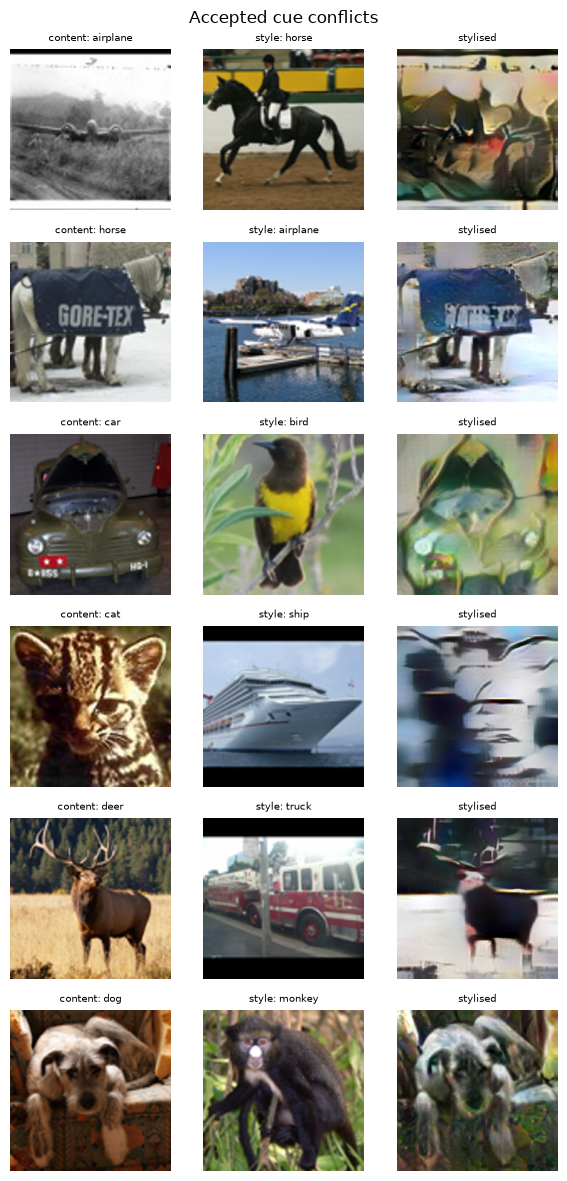

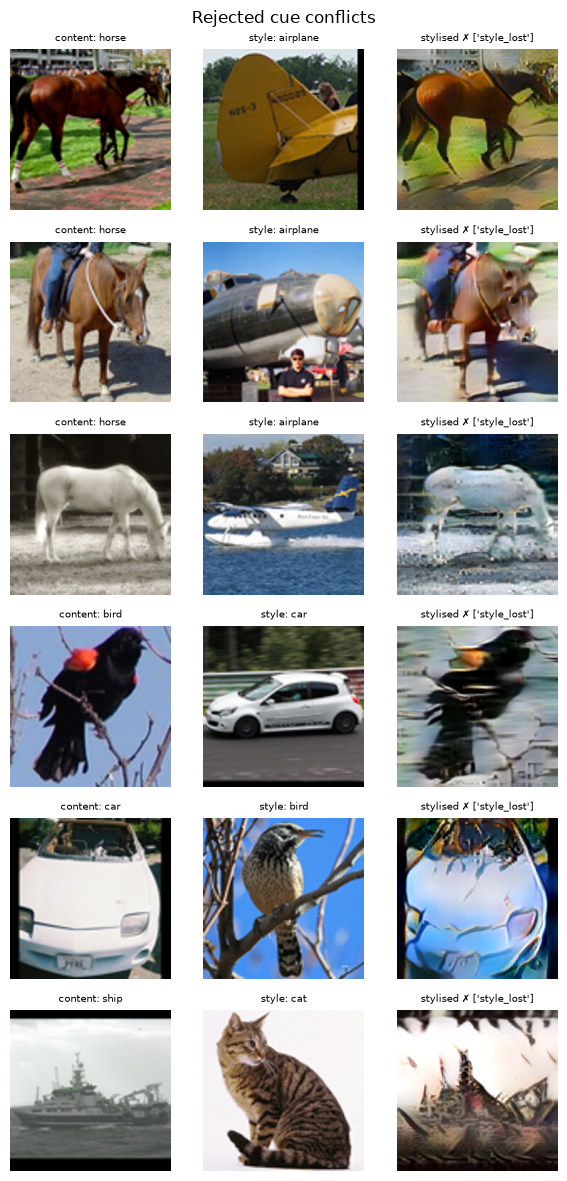

In [11]:
def show(rows, title, fname):
    rows = list(rows)[:6]
    fig, axes = plt.subplots(len(rows), 3, figsize=(6, 2 * len(rows)))
    axes = np.atleast_2d(axes)
    for r_, i in enumerate(rows):
        for c_, (im, t) in enumerate([(content_imgs[i], f"content: {CLASSES[plan[i]['shape_label']]}"),
                                      (style_imgs[i], f"style: {CLASSES[plan[i]['texture_label']]}"),
                                      (stylized[i], "stylised" + ("" if plan[i]["valid"] else f" ✗ {plan[i]['reject_reasons']}"))]):
            axes[r_, c_].imshow(im.permute(1, 2, 0).numpy()); axes[r_, c_].axis("off"); axes[r_, c_].set_title(t, fontsize=7)
    fig.suptitle(title); plt.tight_layout(); plt.savefig(RES / "figures" / fname, dpi=120); plt.show()

show(np.where(df.keep)[0][::40], "Accepted cue conflicts", "cue_conflicts_accepted.png")
rej = np.where(~df.valid)[0]
if len(rej): show(rej[::max(1, len(rej) // 6)], "Rejected cue conflicts", "cue_conflicts_rejected.png")